<a href="https://colab.research.google.com/github/manaraza/SatelliteDataAI-UOA/blob/main/761_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Cloud Clearing in Sentinel-2: combining spectral and clustering approaches

Our goal here is to prepare a Sentinel-2 image over a region of interest and create a cloud-clearing function that uses both:
- Spectral characteristics of clouds (e.g., high reflectance in blue, low in SWIR)
- A clustering algorithm (e.g., k-means or DBSCAN (but do feel free to use whatever you think is best) on pixel features) to find and expand cloud-masked areas to include neighboring “cloudy-ish” pixels.

My intent is that by the end of this lab you have a function that you can then use in many of your project workflows to ensure that the data you are using is as free of clouds as possible (you will need to re-design it if apply to imagery other than Sentinel 2).

The overview of our workflow is to:
- Load and filter on location, date and overall cloud contamination > Sentinel-2 surface reflectance imagery in Earth Engine.
- Apply the s2cloudless cloud probability algorithm.
- Apply a clustering approach to detect “borderline” cloudy pixels near heavy clouds.
- Generate a clean composite for a chosen date range.

We are using this tutorial from Google as the basis of our work: [Sentinel-2 Cloud Masking with s2cloudless](https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless).


**As ever, in this lab whenever we ask you for an visual output, we are expecting you to present it to a publication quality level.**


________________________________________________________________________________
# Implementing S2 Cloudless

In [1]:
# Our usual set up routine
!pip install geemap --quiet

import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

import ee
ee.Authenticate()
ee.Initialize(project='geog761-samana') #<- Remember to change this to your own project's name!

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.9 MB/s eta 0:00:00


First, let us define our area of interest (AOI) and the cloud mask parameters, here is the table from the Earth Engine Catalogue: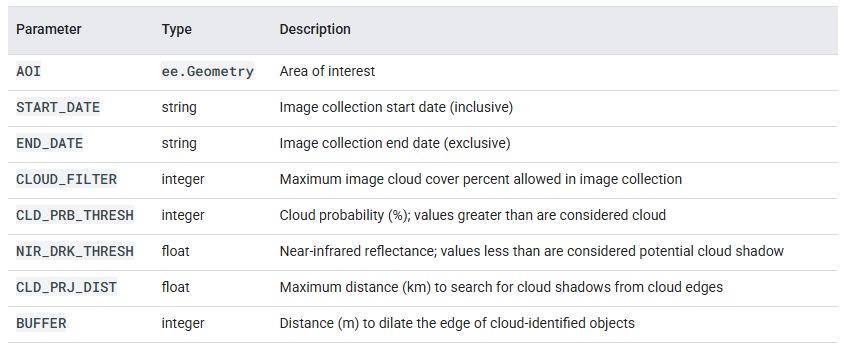

In [2]:
# Control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

Next we use these variables to build a Sentinel 2 image collection. You have done all this before, but now we are using more of the tools at our disposal to get exactly what we want.

Also, from now on we are going to be using functions to make our code more useable and extensible:

In [3]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [4]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [5]:
# As ever, a good idea to do a quick viusalization check
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Yup that is pretty cloudy!

Now, we will define a function to add the s2cloudless probability layer and derived cloud mask as bands to an S2 SR image input.

In [6]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

The next function we need adds bands that adds layers that identify dark pixels, cloud projection, and identified shadows as bands to an S2 SR image input. Note that the image input needs to be the result of the above add_cloud_bands function because it relies on knowing which pixels are considered cloudy (via the renamed 'CLD_PRB_THRESH' band native to this S2 product).

In [7]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

Finally for this stage, we define a function to assemble all of the cloud and cloud shadow components and produce the final mask.

In [8]:
def add_cld_shdw_mask(img):
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER*2/20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

Let us check this out and see how well it is dealing with our famously cloudy country. To do this we will need a function to pull out the cloud masking component layers, as in the 'final' version we will just apply this layer to remove the clouds rather than hold it as something we will display.

In [9]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

The cell you are about to run, is going to open with a whole lot of layers! Use the layer menu top right of the map to turn them all off except the Sentinel 2 image that we are trying to find the cloud in. Then, one by one add in each layer (which is each a part of the cloud clearing algorithim), and look at what 'part' of the cloud problem it is dealing with. Examine how well it is performing and think about what characteristics it is making the decision to label a given pixel as the given target on.

In [10]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Well now! That is considerably better than what we have been using before!

(1) Zoom in to a cloudy region and look at the S2 image, 'clouds' layer, 'dark pixels',  and the 'shadows' layers. Write a short paragraph that discusses:
- The performance of each masking element. Are they perfect or getting confused? What is causing the confusion?
- How do the three elements work together to define pixels that are not clear?
I am looking for you to show an understanding of both the algorithim you have just applied and the underlying spectral sensing principles.

(10 pts)

**1. Performance of each masking element and how they combine:**
The three elements target different physical signatures and perform very differently. The cloud layer (from the S2Cloudless probability model) reliably captures thick, bright cloud, which is spectrally distinct, high reflectance across the visible plus strong cirrus/SWIR response. Its weakness is at thin cirrus and cloud edges, where cloud probability is near the threshold and the mask becomes ragged and fragmented, leaving some hazy pixels uncovered. The dark_pixels layer performs very differently because it is not a cloud detector at all: it simply flags pixels that are dark in the near-infrared (B8) and not water. This massively over-selects, it covers large areas of dark, vegetated hill country and scattered urban pixels that are low-NIR but have nothing to do with clouds, as it is a candidate layer, not a decision. The shadows layer is much tighter and sits predominantly on the downsun side of the cloud, because it is produced by projecting the detected cloud away from the sun and keeping only where that projection intersects dark pixels. Its errors occur where genuinely dark ground (e.g. terrain shade) happens to fall within the projected shadow off the true one.

The three combine as a logical process that turns two weak signals into one. The layer dark_pixels alone is useless; the cloud projection is only geometry. Intersecting them (shadows = cloud_projection * dark_pixels) keeps only dark pixels that are plausible as shadow, discarding dark water and hillshade that are not the downsun of a cloud. The final "not clear" mask is then clouds OR shadows, dilated by a buffer to catch fuzzy edges. Physically, each mask represents a different property, clouds are bright across the visible and cirrus/SWIR; shadows are dark in NIR because they receive only scattered light; water is excluded via the SCL band, so as not to mistake it for shadow, and it is the combination of spectral evidence with sun-cloud geometry that makes the result far more robust than a single threshold.

(2) Exercise: change the above CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, and BUFFER input variables and rerun the previous cells to see how the results change. Present a figure that compares between the first version you ran and your final version. State the values you have selected and describe the improvements in performance you have managed to achieve in the figure caption.

(10 pts)

Finally for this section, let's apply this cloud mask to our data and generate a 'cloud free' image. Replace my parameters used below with the ones you have selected based on your answer to question 2.

In [11]:
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 45
NIR_DRK_THRESH = 0.13
CLD_PRJ_DIST = 2
BUFFER = 75

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [12]:
# Define a function to apply the cloud mask to the S2 spectral bands
def apply_cld_shdw_mask(img):
    cloudmask = img.select('cloudmask')
    # Mask cloudy pixels
    masked_img = img.updateMask(cloudmask.Not())
    # Keep cloudmask and probability bands
    cloudmask_band = img.select('cloudmask')
    probability_band = img.select('probability')
    masked_img = masked_img.addBands([cloudmask_band, probability_band], overwrite=True)
    return masked_img

In [13]:
# Process the collection
s2_sr_median = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .median())

In [14]:
# Display the cloud free composite
def display_cloud_free_mosaic(s2_sr_median, AOI):
    # Create a geemap Map object and center it on the AOI
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add the Sentinel-2 RGB mosaic
    m.addLayer(
        s2_sr_median,
        {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1},
        'S2 cloud-free mosaic')

    return m

display_map = display_cloud_free_mosaic(s2_sr_median, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

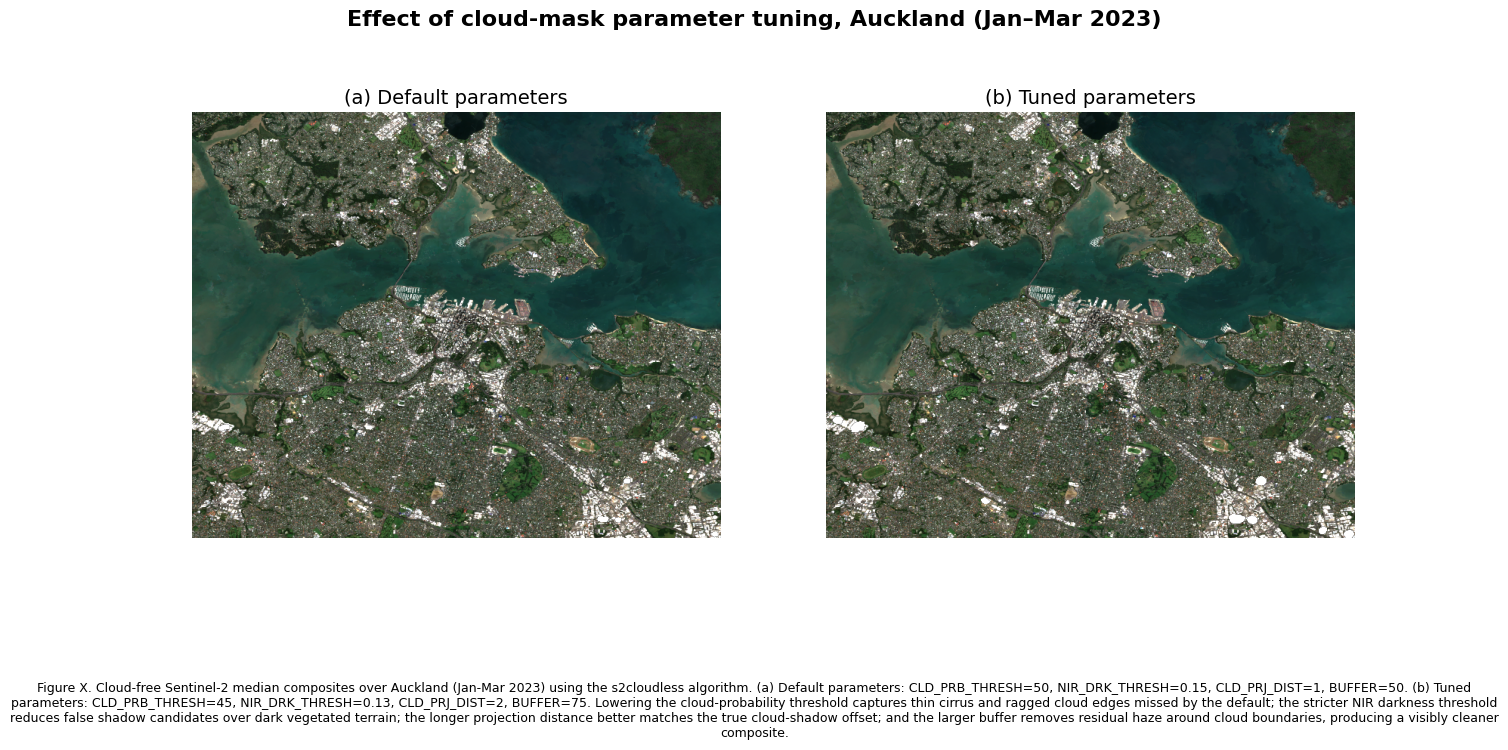

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request, tempfile

def build_composite(prb, nir, prj, buf):
    """Rebuild the cloud-free composite with a given parameter set."""
    global CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, BUFFER
    CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, BUFFER = prb, nir, prj, buf
    col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)
    return (col.map(add_cld_shdw_mask).map(apply_cld_shdw_mask).median())

region = AOI.buffer(8000).bounds()
vis = {'bands': ['B4','B3','B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}

def thumb(img):
    url = img.getThumbURL({'region': region, 'dimensions': 700,
                           'format': 'png', **vis})
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
        urllib.request.urlretrieve(url, f.name)
        return mpimg.imread(f.name)

# BEFORE (lab defaults) and AFTER (your tuned values)
before = build_composite(50, 0.15, 1, 50)
after  = build_composite(45, 0.13, 2, 75)   # <- your chosen values

plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
ax1.imshow(thumb(before)); ax1.axis('off')
ax1.set_title('(a) Default parameters', fontsize=14)
ax2.imshow(thumb(after)); ax2.axis('off')
ax2.set_title('(b) Tuned parameters', fontsize=14)

fig.suptitle('Effect of cloud-mask parameter tuning, Auckland (Jan–Mar 2023)',
             fontsize=16, fontweight='bold')

caption = ('Figure X. Cloud-free Sentinel-2 median composites over Auckland (Jan-Mar 2023) using the '
           's2cloudless algorithm. (a) Default parameters: CLD_PRB_THRESH=50, NIR_DRK_THRESH=0.15, '
           'CLD_PRJ_DIST=1, BUFFER=50. (b) Tuned parameters: CLD_PRB_THRESH=45, NIR_DRK_THRESH=0.13, '
           'CLD_PRJ_DIST=2, BUFFER=75. Lowering the cloud-probability threshold captures thin cirrus '
           'and ragged cloud edges missed by the default; the stricter NIR darkness threshold reduces '
           'false shadow candidates over dark vegetated terrain; the longer projection distance better '
           'matches the true cloud-shadow offset; and the larger buffer removes residual haze around '
           'cloud boundaries, producing a visibly cleaner composite.')
fig.text(0.5, 0.02, caption, ha='center', va='top', wrap=True, fontsize=9)

fig.subplots_adjust(bottom=0.16, top=0.90)
fig.savefig('cloud_param_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('cloud_param_comparison.png')

**Values selected**: CLD_PRB_THRESH = 45 (from 50), NIR_DRK_THRESH = 0.13 (from 0.15), CLD_PRJ_DIST = 2 (from 1), BUFFER = 75 (from 50).

Lowering CLD_PRB_THRESH, captures thin cirrus and ragged cloud edges where the cloud probability sits just below the default cut-off. Lowering NIR_DRK_THRESH, applies a stricter definition of dark in NIR, reducing false shadow candidates over dark vegetated terrain.

Increasing CLD_PRJ_DIST, lengthens the shadow projection to better match the true cloud-shadow offset for the cloud heights in this scene.

Increasing BUFFER dilates the final mask to remove residual haze immediately around cloud boundaries.

Selection Process: I first trialled a more aggressive configuration with (CLD_PRB_THRESH = 40, NIR_DRK_THRESH = 0.12, CLD_PRJ_DIST = 2, BUFFER = 100).  This visibly degraded the composite, bright urban surfaces in central and souther Auckland were incorrectly classified as cloud and then dilated by the larger buffer, leaving distinct white data gaps that were absent under the defaults. I therefore changed the configurations, which retains the beneficial change to the shadow projection distance while avoiding false positives over built-up areas. The final composite is free of these artefacts.

Trade-off: For this AOI and date range the default parameters already produced a near cloud-free composite, so the visible gains from tuning were marginal. The exercise nonetheless demonstrates the central trade-off in cloud masking: more aggressive thresholds remove more cloud but progressively sacrifice valid observations, and the optimal setting is scene-dependant.

Now THAT is a cloud-free image! (Well, with my thresholds we still have a little there over the SW forest, can yours do better?).

(3) This process has managed to avoid masking out the many bright white roofs of Auckland as cloud, despite them appearing very similar to cloud in the RGB visualization. How has the algorithm achieved this?
(5 pts)


________________________________________________________________________________

**Answer:**
Because the decision is not made on RGB brightness. S2cloudless classifies on the full multispectral signature, so it can use wavelengths where cloud and bright ground diverge. The key ones are the SWIR bands (B11, B12), cloud droplets absorb strongly in the shortwave infrared while dry-built surfaces like metal, concrete and tile stay relatively bright, and the cirrus band (B10), which responds to scattering high in the atmosphere, something ground surfaces cannot miimc. Pixels that are indistinguishable in blue, green and red therefore separate cleanly here.
A second, independent check reinforces this shadows are only labelled where a cloud projected downsun, intersects dark NIR pixels. A rooftop has no cloud projected onto it, so it can never be masked as shadow.
In short, cloud detection here is physically-grounded multispectral classification combined with sun-cloud geometry, not a brightness threshold.

# Extending S2 Cloudless with a clustering approach
The process we explored in the prior section has worked really rather well! But you saw in the exercise that it does rely on you setting the local paramaters. This is a manual process and one that is at risk of reduced effectiveness if we are clearing cloud over a wide area. This is particularly the case for cirrus and other thin clouds (e.g. cloud edges) that the thresholds are very sensitive to.

Therefore, let us extend our cloud-clearing algorithim into one that includes a clustering-step in which we sample the pixels around the edge of our clouds and test if they should be clustered into our cloud mask.

We will now implement the following workflow:
1.   Reset our data stack, with somewhat worse settings than the very good ones we have just set, in order to make this a better (for humans) teaching exercise.
2.   Define what counts as inside a cloud, outside a cloud and the edge of a cloud.
3.   Vizualize these samples and determine if we can perform meaningful clustering on them.
4.   Perform clustering of the border zone pixels with either the clouds or the cloud free.





In [16]:
# First, lets make our cloud clearing 'worse' in order to more clearly demonstrate our clustering alg
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 30
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Re-run s2cloudless approach, this time with .moasic as the compositing operator
s2_sr_mosaic = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .mosaic()) #<- switched to mosaic to better preserve the cloud masking layers we want to now use for our k-means workflow

In [17]:
def define_cloud_zones(img, edge_buffer=120):
    cloudmask = img.select('cloudmask')

    # Interior cloud pixels: cloudmask==1, away from edges (small erosion)
    cloud_interior = cloudmask.selfMask().focal_min(3)

    # Interior clear pixels: cloudmask==0, away from edges (medium erosion)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels: buffer zone around clouds, but outside cloudmask
    cloud_edge = cloudmask.focal_max(edge_buffer / 10).And(cloudmask.Not())

    return cloud_interior, clear_interior, cloud_edge


In [18]:
def sample_zones(img, AOI, edge_buffer=20):
    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B9', 'B8', 'B11', 'B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples = img_for_sampling.updateMask(cloud_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=0, geometries=True)

    clear_samples = img_for_sampling.updateMask(clear_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=1, geometries=True)

    edge_samples = img_for_sampling.updateMask(cloud_edge).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=2, geometries=True)

    return cloud_samples, clear_samples, edge_samples


In [19]:
# Gather our samples
cloud_samples, clear_samples, edge_samples = sample_zones(s2_sr_mosaic, AOI)

# Function to convert a earth engine feature class to a pandas df
def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)


# Carry out the conversion and sanity print out what we have
cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")
print("Cloud columns:", cloud_df.columns)


Cloud samples: 727
Clear samples: 4310
Edge samples: 1930
Cloud columns: Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'probability',
       'longitude', 'latitude'],
      dtype='object')


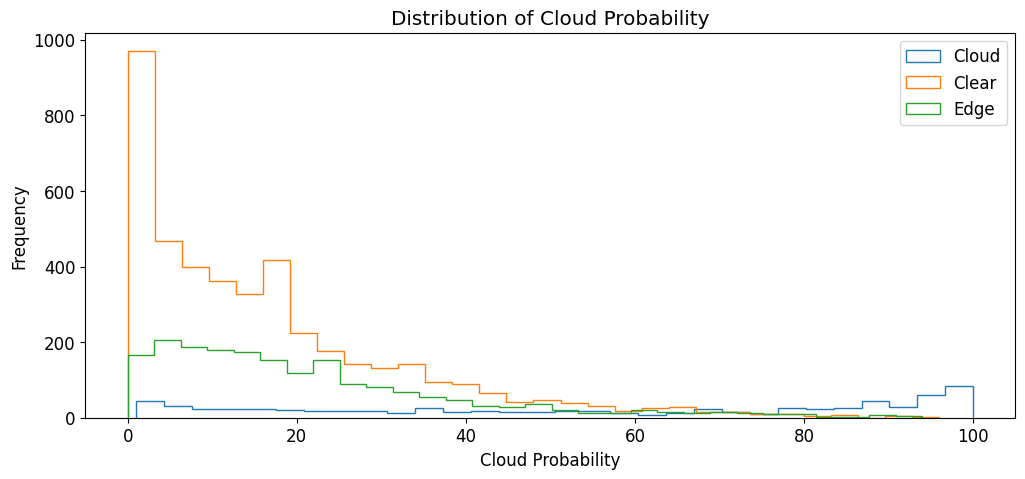

In [20]:
# Histogram of cloud probability by class
plt.figure(figsize=(12, 5))
plt.hist(cloud_df['probability'], bins=30, histtype='step', label='Cloud')
plt.hist(clear_df['probability'], bins=30, histtype='step', label='Clear')
plt.hist(edge_df['probability'], bins=30, histtype='step', label='Edge')
plt.xlabel('Cloud Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Cloud Probability')
plt.show()

Look at the histogram above. What is it telling you about the quality of the training classes you have just created? Think back to Lab 1, and the lecture 2/3 exercises.

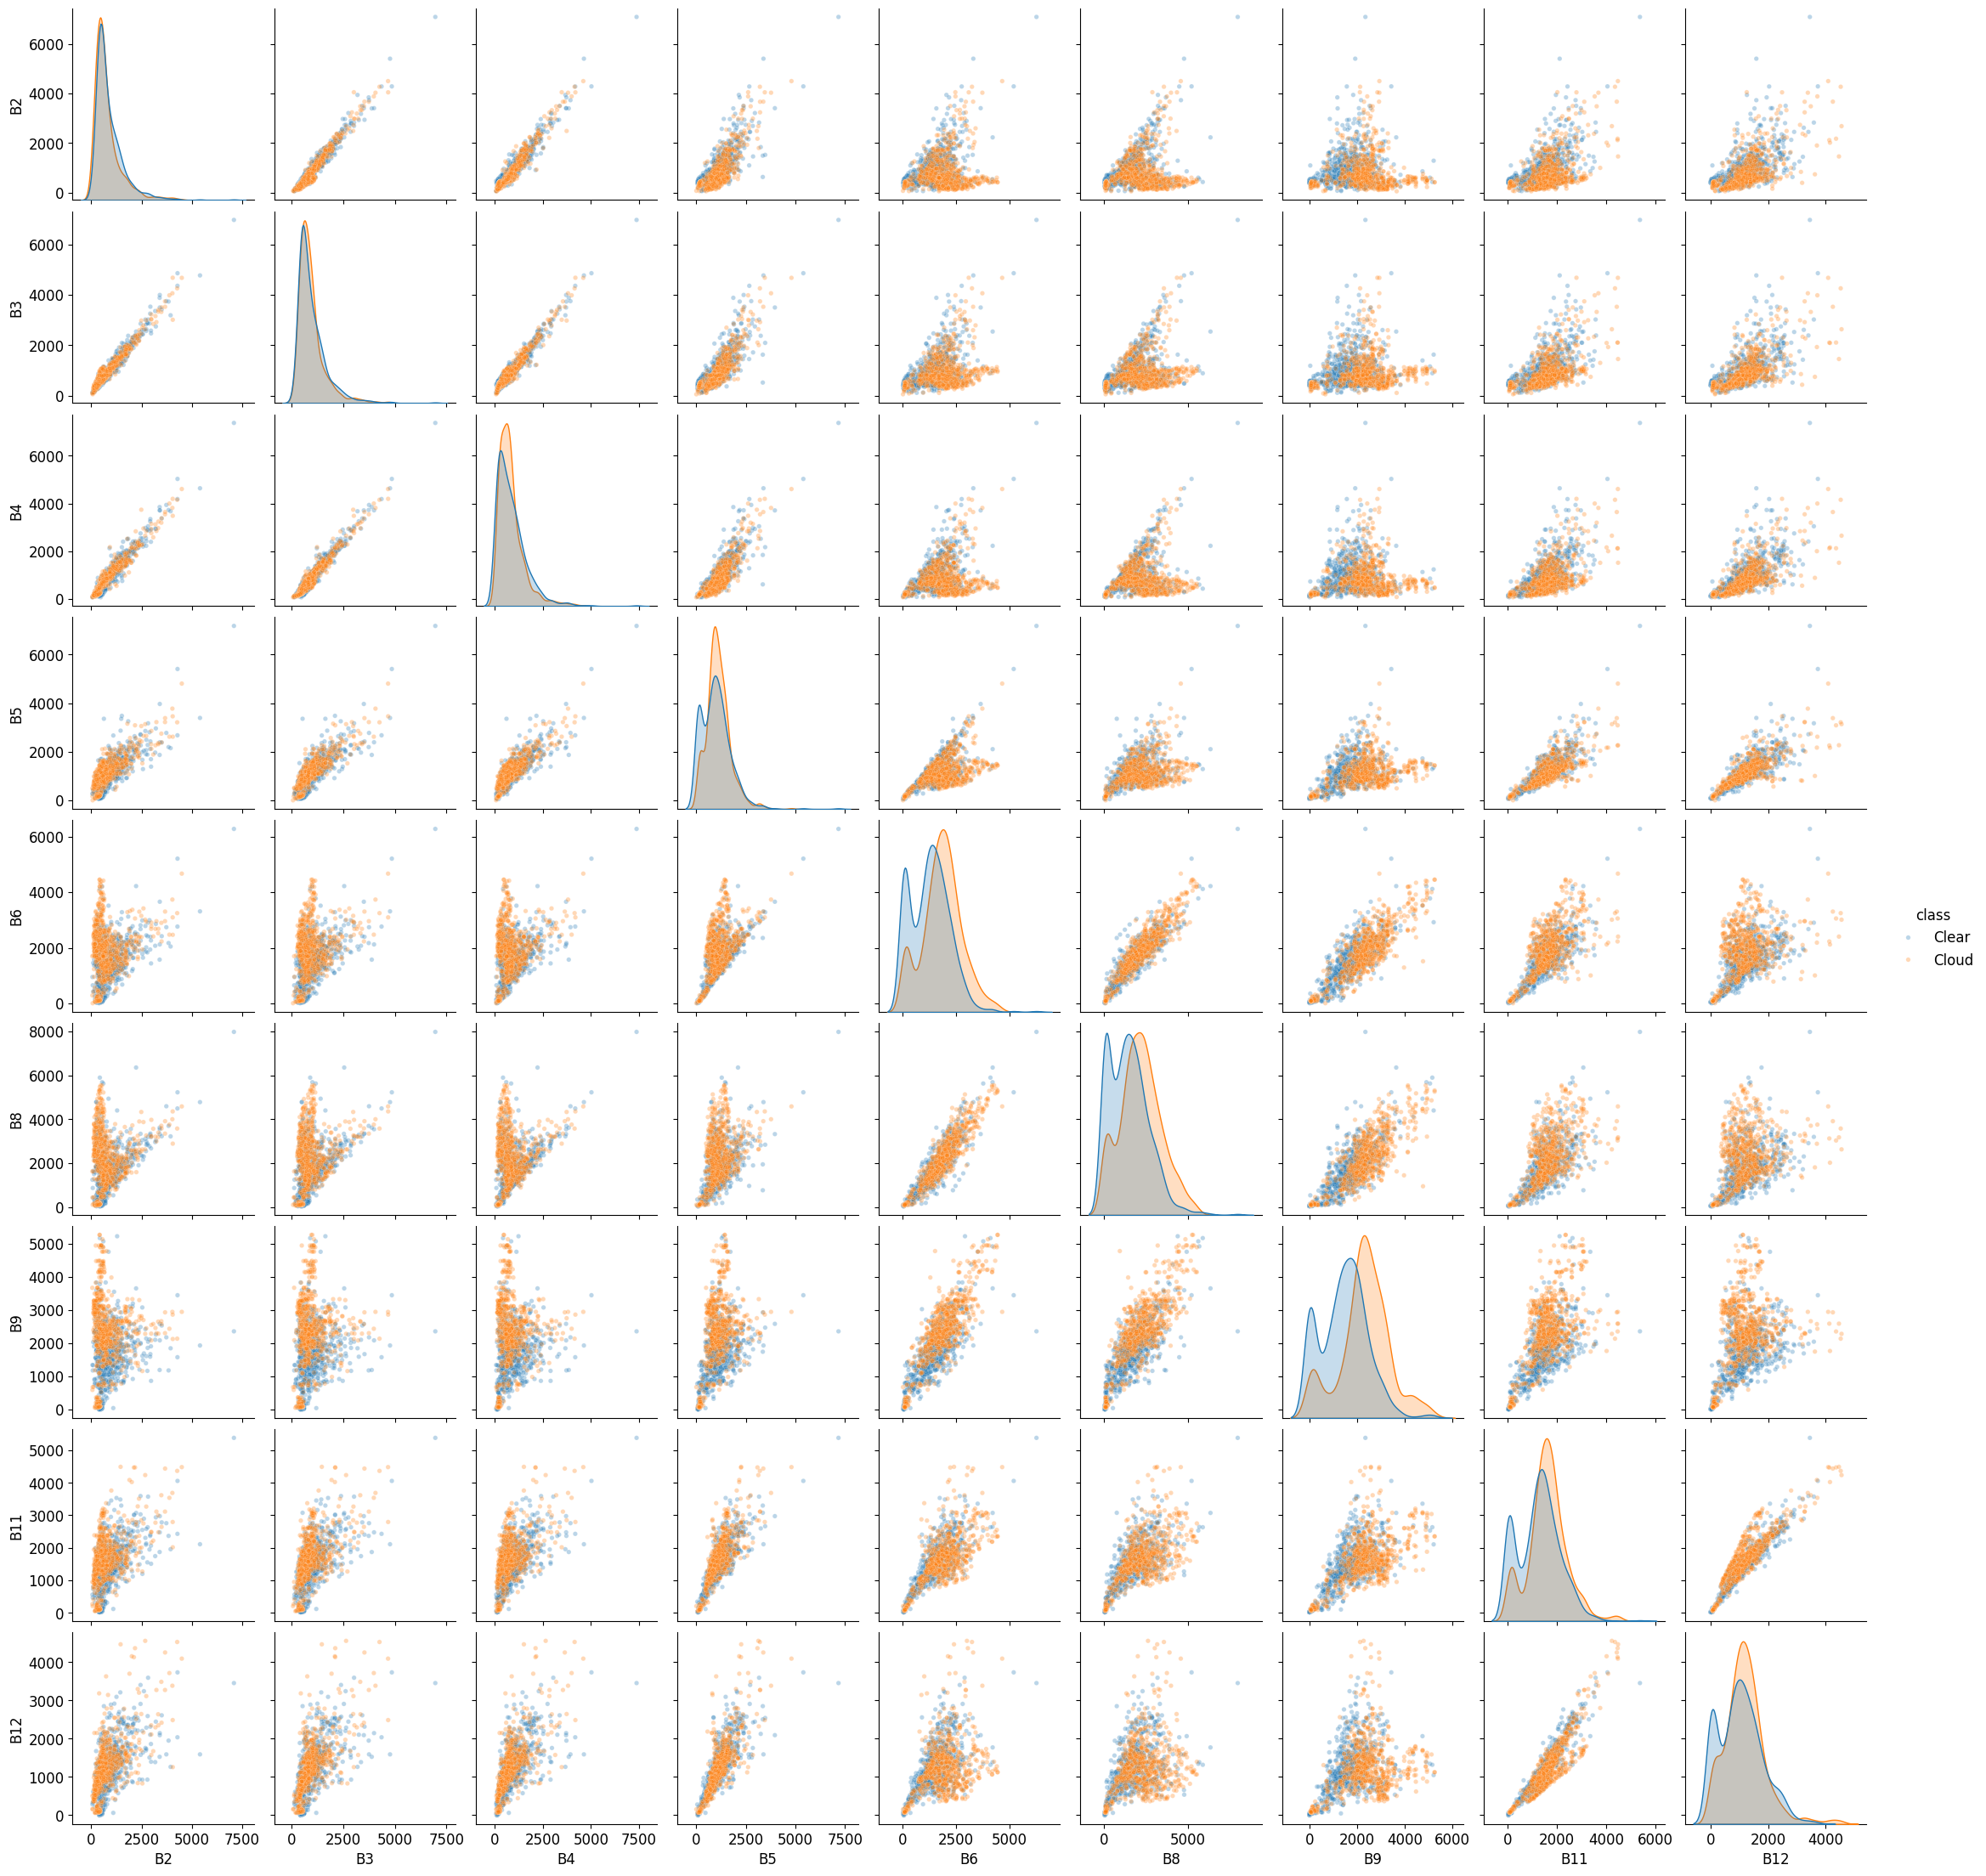

In [21]:
# Plot out all the bands, by the two 'labelled' classes that we want to discriminate between
# Add class labels
cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'

# Combine to one df
combined_df = pd.concat([cloud_df, clear_df])

# We will carry out somne class balancing here
# Find smallest class count
min_count = combined_df['class'].value_counts().min()

# Downsample each class to min_count
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

# Now plot with balanced_df
# This is going to make a big plot that you will have to scroll around! Pay particular attention to the histogram plots on the diagonal.
bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B8', 'B9', 'B11', 'B12']
sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)


(4) What do the histograms of cloud detection probability (as judged by s2cloudless) plotted in the three classes we have set here, AND the pair plot of all bands available tell us about our ability to tell cloudy vs non-cloud pixels apart? Make sure to explain your answer with reference to physical principles and the statistical foundations of ML (5 pts)

**Answer:**
The histograms show noisy, imbalanced classes. Clear peaks near 0 but tails to 60-80, while Cloud has a bump near 0-10 because the dilated mask swept clear pixels into the Cloud label. Edge spreads across the middle, confirming those pixels are actually ambiguous.
The pair-plot shows separability depends on band choice. The visible bands (B2-B4) overlap almost completely, since cloud and bright urban surfaces both reflect strongly there. Separation improves in B8, B9, B11 and B12: cloud droplets scatter strongly to give a flat, bright spectrum, while the water-vapour and SWIR bands respond to atmospheric path and moisture in ways ground surfaces cannot mimic.
Statistically, classification needs class distributions whose means are separated relative to their variances. Where they overlap, any boundary misclassifies a fraction of pixels regardless of algorithm, so feature choice matters more than classifier choice.


(5) Which bands are therefore going to be the best to use in our K-means clustering approach and why? (5 pts)

**Answer:**
The best features are B8(NIR), B9(water vapour), B11 and B12(SWIR), optionally with probability.
The default ['B2', 'B3', 'B4'] is a poor choice: the pair-plot showed near-total overlap there, because bright ground (roofs, sand, bare soil) reflects as strongly in the visible as cloud does.
The selected bands are where the physical separation is real. Cloud droplets scatter strongly to give a flat, bright spectrum, while land surfaces are spectrally structured; B9 responds to atmospheric water vapour, keying off the fact that cloud sits high in the atmosphere, something no ground surface can replicate. These are exactly the bands where the pair-plot showed Cloud sitting consistently higher than Clear.
This matters because k-means is distance-based: it assigns pixels to the nearest cluster centre, so performance depends entirely on whether the features places the classes far apart.
**Observed effect**:
With the default bands, k-means split the edge pixels along a single brightness diagonal and assigned the dim pixels to Cloud, physically backwards, labelling 1512 of 1930 edge pixels (78%) as cloud. Switching to ['B8', 'B9', 'B11', 'B12'] produced a physically sensible split, with the bright, high-NIR/SWIR pixels correctly identified as cloud, and reclassified around 300 pixels to Clear (1216 Cloud / 714 Clear). This recovers valid bright surface pixels that the visible-band clustering had wrongly masked.


With our choices made, let us now test if we can implement k-means as a tool by which to assign those edge pixels into either the cloudy or clear classes. Noting that I have placed default band choices in the 'features to use for clustering' line. You do not need to use just three bands.

Run this section first with the default bands, and then change it to the ones you have selected in question 5. Observe the difference it makes...

In [22]:
# Use the balanced_df from before for cloud and clear pixels only
train_df = balanced_df[balanced_df['class'].isin(['Cloud', 'Clear'])]

# Features to use for clustering
features = ['B8', 'B9', 'B11', 'B12']

# Prepare training data (cloud=1, clear=0)
X_train = train_df[features].values
y_train = (train_df['class'] == 'Cloud').astype(int).values

# Fit k-means with 2 clusters on training data
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_train)

# Map clusters to classes by majority vote on training data
labels, counts = np.unique(kmeans.labels_[y_train==0], return_counts=True)
clear_cluster = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans.labels_[y_train==1], return_counts=True)
cloud_cluster = labels[np.argmax(counts)]

# Prepare edge pixels data for prediction
edge_features = edge_df[features].values

# Predict clusters for edge pixels
edge_clusters = kmeans.predict(edge_features)

# Assign class labels to edge pixels based on cluster
edge_df['predicted_class'] = ['Cloud' if c == cloud_cluster else 'Clear' for c in edge_clusters]

# Quick summary
print(edge_df['predicted_class'].value_counts())


predicted_class
Cloud    1216
Clear     714
Name: count, dtype: int64


And now plot up the results of this below. Play around with this plotting and take a look at each set of band combinations you have chosen. Think about where the boundary is being placed, does it make sense?

predicted_class
Cloud    1216
Clear     714
Name: count, dtype: int64


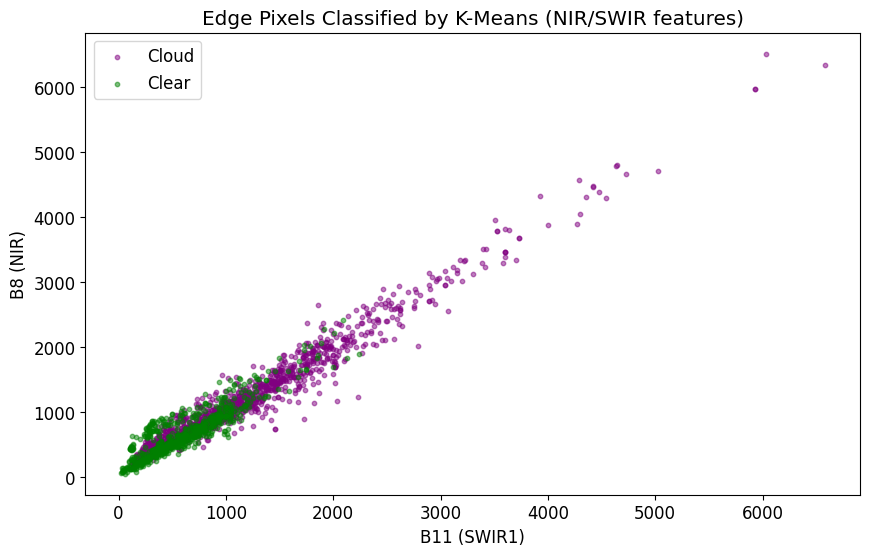

In [23]:
# Count of predicted classes
counts = edge_df['predicted_class'].value_counts()
print(counts)

# Scatter plot of edge pixels B4 vs B3 colored by predicted class ### CHANGE THIS TO YOUR OTHER BANDS ###
plt.figure(figsize=(10, 6))
for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]
    plt.scatter(subset['B4'], subset['B3'], label=label, alpha=0.5, s=10, c=color)

plt.xlabel('B11 (SWIR1)')
plt.ylabel('B8 (NIR)')
plt.title('Edge Pixels Classified by K-Means (NIR/SWIR features)')
plt.legend()
plt.show()


Finally, we will map this back onto earth engine via the following workflow:
1.  Export the classified edge pixels back to Earth Engine as a FeatureCollection
2. Rasterize the classified edge points into an image layer
3. Visualize refined cloud mask in Earth Engine (geemap):

Export to Earth Engine FC:

In [24]:
# Function to go the other way! This time from a dataframe to the feature collection
def df_to_ee_fc(df):
    features = []
    for _, row in df.iterrows():
        geom = ee.Geometry.Point([row['longitude'], row['latitude']])
        props = {k: float(row[k]) for k in ['B8', 'B9', 'B11', 'B12', 'probability']}
        props['predicted_class'] = row['predicted_class']
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

edge_fc = df_to_ee_fc(edge_df)

Rasterize into image layer:

In [25]:
# Map predicted class to numeric
def class_to_numeric(feature):
    cls = feature.get('predicted_class')
    return feature.set('cloud_refined', ee.Number(ee.Algorithms.If(ee.String(cls).equals('Cloud'), 1, 0)))

edge_fc_num = edge_fc.map(class_to_numeric)

# Rasterize: paint 'cloud_refined' on a blank image
refined_cloud_mask = edge_fc_num.reduceToImage(
    properties=['cloud_refined'],
    reducer=ee.Reducer.first())

# Optionally, you can combine this refined mask with your existing cloudmask for a final refined mask
final_mask = s2_sr_median.select('cloudmask').max(refined_cloud_mask).rename('cloudmask_refined')


Visualize it:

In [26]:
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(AOI, 12)

# Show original cloudmask
Map.addLayer(s2_sr_median.select('cloudmask'), {'palette': ['white', 'red']}, 'Original cloudmask')

# Show refined cloudmask
Map.addLayer(final_mask.selfMask(), {'palette': ['blue']}, 'Refined cloudmask')

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Hopefully, what you should now see above is a patch of downtown Auckland that has your s2cloudless cloudmask and a scatter of blue pixels (i.e. the sample from within the AOI) that k-means has decided is cloud.

Your answer to Q5 should see this scatter of 'new cloudy' pixels be better associated with the known clouds than if you leave it as the default bands that I have provided.





(6) Exercise: take all you have learned in this lab and carry out the following improvements:
1. Increase the K-means sampling to be more representative of the whole scene. This means; sample regions for cloud, clear and cloud edge that are not just over downtown Auckland but from across multiple landcover types.
2. Take the model that you have trained here using SciKitLearn and use it to classify edge pixels across a whole satellite image.

Present your results in **two** figures. The first should show the results of upgrades to pt.1, the second the results of pt.2.

(15 pts)

To get you started on item 2, this might be how you plan out your workflow given that you cannot upload a python ML model directly to Earth Engine:
- Extract cluster centres from Python k-means.
- Pass centres as constants into EE.
- Write a per-pixel classification function assigning nearest cluster centre.
- Apply this function to edge pixels or the whole image as needed.

In [28]:
# Q6 PART 1: sample across multiple land-cover types
import pandas as pd

def fc_to_df(fc, max_features=4500):
    """Convert an EE FeatureCollection to a pandas DataFrame."""
    features = fc.limit(max_features).getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)

# Sites spanning urban, forest, farmland and coastal water around Auckland (lon, lat)
SITES = {
    'Downtown Auckland': [174.7633, -36.8485],
    'Waitakere forest':  [174.5400, -36.9200],
    'South farmland':    [174.9400, -37.1200],
    'Hauraki Gulf':      [174.9000, -36.7500],
    'North Shore urban': [174.7500, -36.7600],
}

def sample_zones_multi(img, sites, buffer_m=3000, edge_buffer=20, n=800):
    """Sample cloud / clear / edge pixels at several sites and pool them.
       n=800 per site x 5 sites stays under EE's 5000-element getInfo limit."""
    cloudmask = img.select('cloudmask')
    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge     = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2','B3','B4','B5','B6','B9','B8','B11','B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')
    img_s = img.select(sample_bands)

    cloud_parts, clear_parts, edge_parts = [], [], []
    for i, (name, lonlat) in enumerate(sites.items()):
        region = ee.Geometry.Point(lonlat).buffer(buffer_m)
        cloud_parts.append(img_s.updateMask(cloud_interior).sample(
            region=region, scale=10, numPixels=n, seed=i, geometries=True))
        clear_parts.append(img_s.updateMask(clear_interior).sample(
            region=region, scale=10, numPixels=n, seed=100+i, geometries=True))
        edge_parts.append(img_s.updateMask(cloud_edge).sample(
            region=region, scale=10, numPixels=n, seed=200+i, geometries=True))

    merge = lambda parts: ee.FeatureCollection(parts).flatten()
    return merge(cloud_parts), merge(clear_parts), merge(edge_parts)

cloud_s, clear_s, edge_s = sample_zones_multi(s2_sr_mosaic, SITES)
cloud_df2, clear_df2, edge_df2 = fc_to_df(cloud_s), fc_to_df(clear_s), fc_to_df(edge_s)
print(f"Cloud: {len(cloud_df2)}  Clear: {len(clear_df2)}  Edge: {len(edge_df2)}")

Cloud: 882  Clear: 2545  Edge: 696


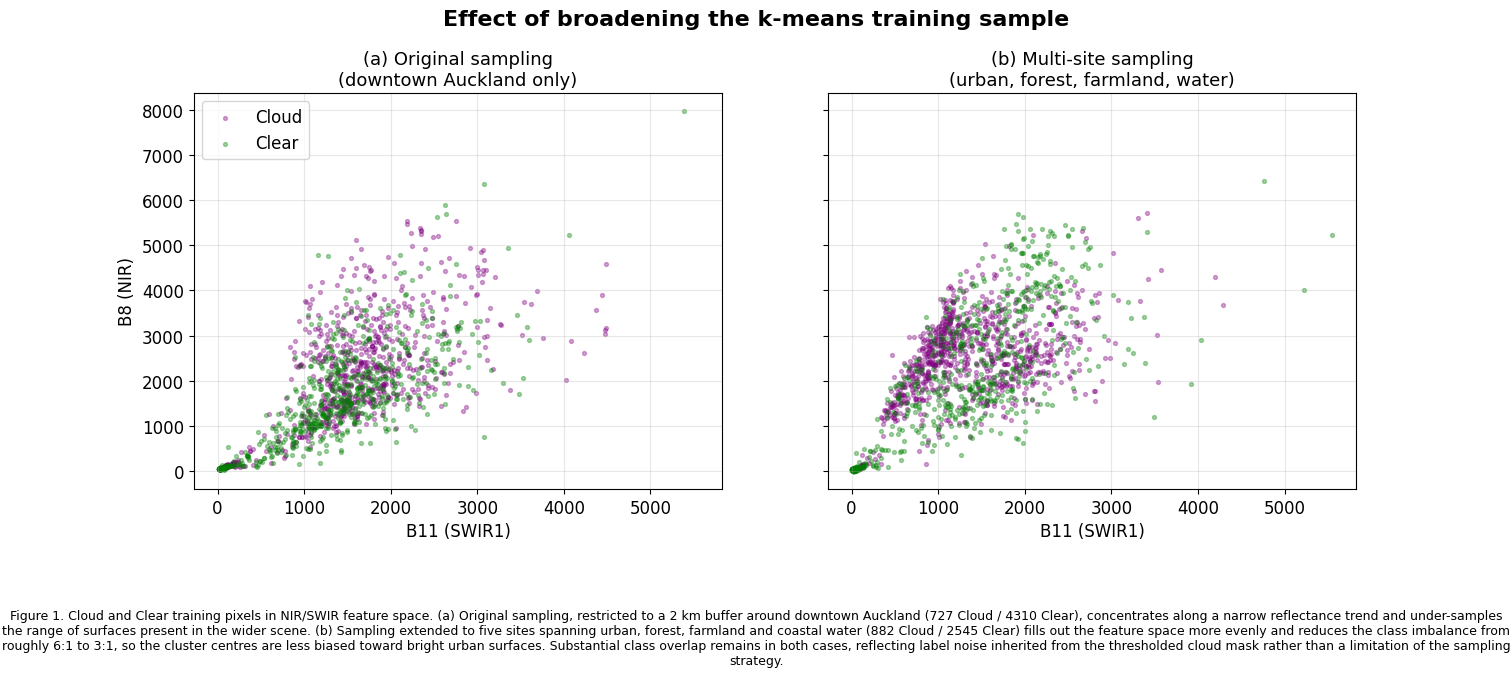

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
import matplotlib.pyplot as plt

cloud_df2['class'] = 'Cloud'; clear_df2['class'] = 'Clear'
combined2 = pd.concat([cloud_df2, clear_df2])
min_count = combined2['class'].value_counts().min()
balanced2 = combined2.groupby('class').sample(n=min_count, random_state=42)

plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

panels = [
    (balanced_df, '(a) Original sampling\n(downtown Auckland only)'),
    (balanced2,   '(b) Multi-site sampling\n(urban, forest, farmland, water)'),
]
for ax, (df, title) in zip(axes, panels):
    for cls, colour in [('Cloud', 'purple'), ('Clear', 'green')]:
        sub = df[df['class'] == cls]
        ax.scatter(sub['B11'], sub['B8'], s=8, alpha=0.35, c=colour, label=cls)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('B11 (SWIR1)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('B8 (NIR)'); axes[0].legend()

fig.suptitle('Effect of broadening the k-means training sample', fontsize=16, fontweight='bold')
caption = ('Figure 1. Cloud and Clear training pixels in NIR/SWIR feature space. '
    '(a) Original sampling, restricted to a 2 km buffer around downtown Auckland '
    '(727 Cloud / 4310 Clear), concentrates along a narrow reflectance trend and '
    'under-samples the range of surfaces present in the wider scene. '
    '(b) Sampling extended to five sites spanning urban, forest, farmland and coastal '
    'water (882 Cloud / 2545 Clear) fills out the feature space more evenly and reduces '
    'the class imbalance from roughly 6:1 to 3:1, so the cluster centres are less biased '
    'toward bright urban surfaces. Substantial class overlap remains in both cases, '
    'reflecting label noise inherited from the thresholded cloud mask rather than a '
    'limitation of the sampling strategy.')
fig.text(0.5, 0.02, caption, ha='center', va='top', wrap=True, fontsize=9)
fig.subplots_adjust(bottom=0.22, top=0.88)
fig.suptitle('Effect of broadening the k-means training sample',
             fontsize=16, fontweight='bold', y=1.02)
fig.savefig('sampling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('sampling_comparison.png')

Cloud centre: [2816.0, 2910.8, 1594.3, 1035.6]
Clear centre: [435.6, 498.8, 287.2, 203.5]
original: 6.7% of scene masked
refined: 10.5% of scene masked
Increase: +3.8 percentage points


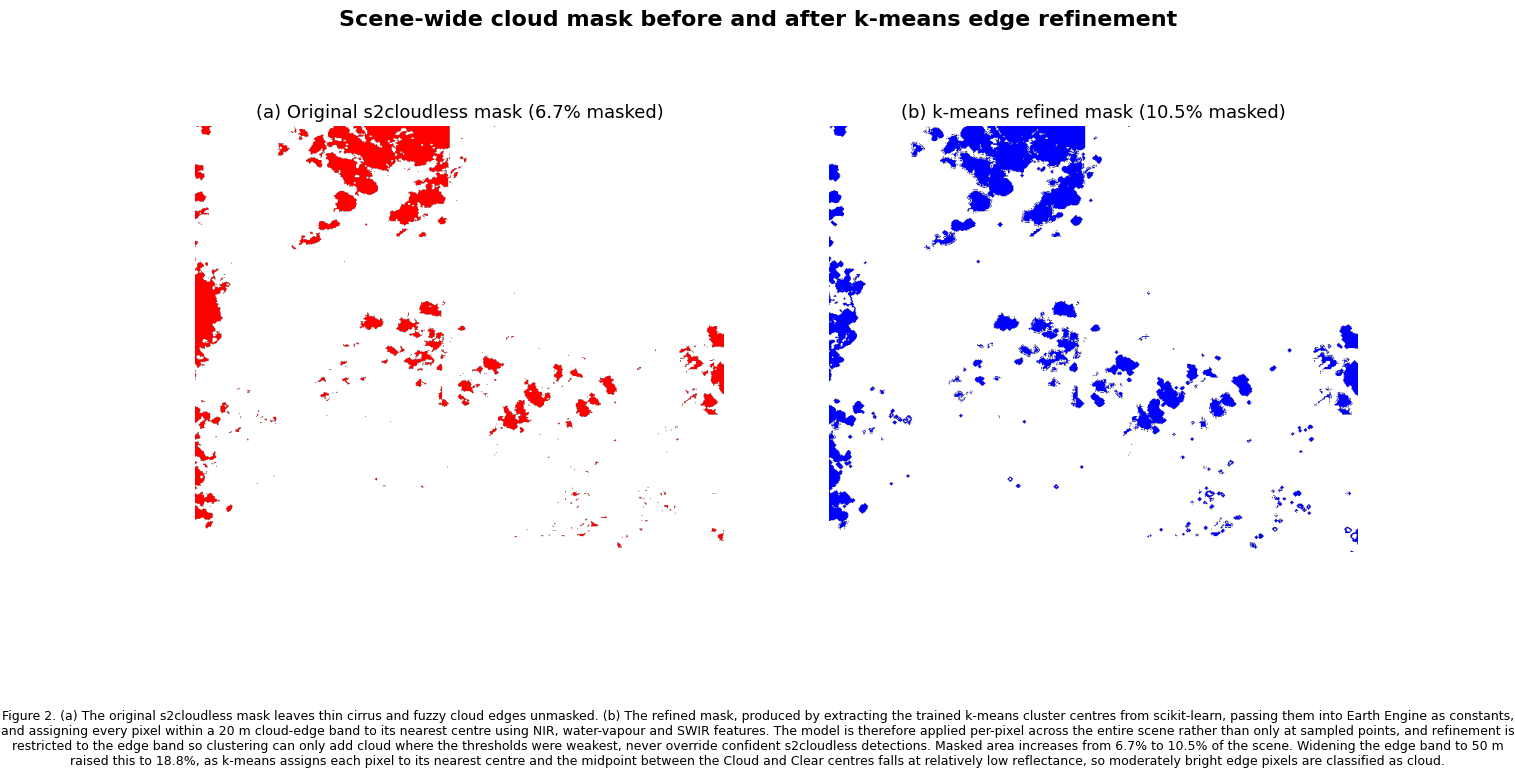

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# Q6 PART 2: apply the trained model scene-wide in Earth Engine

from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request, tempfile

features = ['B8', 'B9', 'B11', 'B12']

#Retrain on the broader multi-site sample from Part 1
X2 = balanced2[features].values
y2 = (balanced2['class'] == 'Cloud').astype(int).values
kmeans2 = KMeans(n_clusters=2, random_state=42).fit(X2)

lab, cnt = np.unique(kmeans2.labels_[y2 == 1], return_counts=True)
cloud_cluster2 = lab[np.argmax(cnt)]

#Key step: reduce the trained model to its cluster centres
centres = kmeans2.cluster_centers_
cloud_centre = centres[cloud_cluster2].tolist()
clear_centre = centres[1 - cloud_cluster2].tolist()
print('Cloud centre:', [round(v, 1) for v in cloud_centre])
print('Clear centre:', [round(v, 1) for v in clear_centre])

def classify_by_nearest_centre(img, bands, cloud_c, clear_c):
    """Reimplement k-means' decision rule as EE image math:
       for each pixel, squared distance to each centre, assign the nearer one."""
    feat = img.select(bands)
    def sq_dist(centre):
        total = ee.Image.constant(0)
        for b, c in zip(bands, centre):
            diff = feat.select(b).subtract(ee.Image.constant(c))
            total = total.add(diff.pow(2))
        return total
    return sq_dist(cloud_c).lt(sq_dist(clear_c)).rename('kmeans_cloud')

kmeans_cloud = classify_by_nearest_centre(s2_sr_mosaic, features, cloud_centre, clear_centre)

#Restrict refinement to a narrow 20 m edge band (2 px at 10 m)
cloudmask = s2_sr_mosaic.select('cloudmask')
edge_zone = cloudmask.focal_max(2).And(cloudmask.Not())
refined   = cloudmask.max(kmeans_cloud.And(edge_zone)).rename('cloudmask_refined')

#Quantify how much extra area is masked
region2 = AOI.buffer(10000).bounds()
stats = {}
for name, m in [('original', cloudmask), ('refined', refined)]:
    v = m.rename('m').reduceRegion(ee.Reducer.mean(), region2, scale=60,
                                   maxPixels=1e9).getInfo()
    stats[name] = v['m'] * 100
    print(f"{name}: {stats[name]:.1f}% of scene masked")
print(f"Increase: +{stats['refined'] - stats['original']:.1f} percentage points")

# Figure 2
def mask_thumb(img, palette):
    url = img.selfMask().visualize(**{'min':0,'max':1,'palette':palette}).getThumbURL(
        {'region': region2, 'dimensions': 700, 'format':'png'})
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
        urllib.request.urlretrieve(url, f.name)
        return mpimg.imread(f.name)

plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(mask_thumb(cloudmask, ['red']))
axes[0].axis('off')
axes[0].set_title(f"(a) Original s2cloudless mask ({stats['original']:.1f}% masked)", fontsize=13)
axes[1].imshow(mask_thumb(refined, ['blue']))
axes[1].axis('off')
axes[1].set_title(f"(b) k-means refined mask ({stats['refined']:.1f}% masked)", fontsize=13)

fig.suptitle('Scene-wide cloud mask before and after k-means edge refinement',
             fontsize=16, fontweight='bold', y=1.02)

caption = (
    'Figure 2. (a) The original s2cloudless mask leaves thin cirrus and fuzzy cloud edges '
    'unmasked. (b) The refined mask, produced by extracting the trained k-means cluster '
    'centres from scikit-learn, passing them into Earth Engine as constants, and assigning '
    'every pixel within a 20 m cloud-edge band to its nearest centre using NIR, water-vapour '
    'and SWIR features. The model is therefore applied per-pixel across the entire scene '
    'rather than only at sampled points, and refinement is restricted to the edge band so '
    'clustering can only add cloud where the thresholds were weakest, never override '
    f"confident s2cloudless detections. Masked area increases from {stats['original']:.1f}% "
    f"to {stats['refined']:.1f}% of the scene. Widening the edge band to 50 m raised this to "
    '18.8%, as k-means assigns each pixel to its nearest centre and the midpoint between the '
    'Cloud and Clear centres falls at relatively low reflectance, so moderately bright edge '
    'pixels are classified as cloud.'
)
fig.text(0.5, 0.02, caption, ha='center', va='top', wrap=True, fontsize=9)

fig.subplots_adjust(bottom=0.20, top=0.90)
fig.savefig('kmeans_scene_refinement.png', dpi=300, bbox_inches='tight')
plt.show()

# Download both Q6 figures
from google.colab import files
files.download('kmeans_scene_refinement.png')
files.download('sampling_comparison.png')

**Answer:**
 **Improvements to the k-means cloud-edge refinement**
 The point-based refinement was confined to downtown Auckland and refind only sampled points, not every edge pixel in the scene.

 Part1 : More representative sampling
 The original sampling drew only from a 2 km buffer around downtown Auckland, so the Clear class was dominated by bright urban surfaces. Extending it to five sites spanning urban, forest, farmland and coastal water fills out the NIR/SWIR feature space more evenly and reduces the class imbalance from roughly 6:1 to 3:1 (727/4310 leads to 882/2545), so the cluster centres are no longer biased toward bright city surfaces. Overlap remains, but stems from label noise inherited from the threshold mask rather than sampling location.

 Part2: Applying the model scene-wide
A scikit-learn model cannot be uploaded to Earth Engine, so I transferred its decision rule instead. K-means is simply nearest-centre assignment, so I extracted the two cluster centres and passed them into EE as constants, and implemented the rule as image arithmetic. Refinement was also restricted to a narrow edge band so clustering can only add cloud where thresholds were weakest; with a 20 m band, masked area rises from 6.7% to 10.5%.

Widening the band to 50 m raised the masked area to 18.8%, as more moderately bright edge pixels fall nearer the Cloud centre, the same trade-off as Q2.